In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model


In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
data_dirs = {
    "train": "../affectnet_dataset/Train",
    "test": "../affectnet_dataset/Test"
}

keypoints_dir = "../keypoints_dataset"

os.makedirs(keypoints_dir, exist_ok=True)

In [4]:
EPOCHS = 50
RANDOM_SEED = 40
BATCH_SIZE = 32
EMOTIONS = ['Anger', 'Contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [5]:
mp_holistic = mp.solutions.holistic # Holistic model 
mp_drawing = mp.solutions.drawing_utils # Drawing utilities 
mp_face_mesh = mp.solutions.face_mesh

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [8]:

def extract_keypoints(results):
    if results.face_landmarks:
        face = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
        )

        # center
        center = face.mean(axis=0)
        face = face - center

        # scale normalize
        scale = np.linalg.norm(face.max(axis=0) - face.min(axis=0))
        if scale != 0:
            face = face / scale

        return face.flatten()
    else:
        return np.zeros(468 * 3)

In [ ]:
# # Extract keypoints and save as .npy files
# with mp_holistic.Holistic(static_image_mode=True) as holistic:
#     for split, split_dir in data_dirs.items():
#         for class_name in sorted(os.listdir(split_dir)):
#             class_path = os.path.join(split_dir, class_name)
#             if not os.path.isdir(class_path):
#                 continue
            
#             # Make parallel folder in keypoints_dir
#             save_class_path = os.path.join(keypoints_dir, split, class_name)
#             os.makedirs(save_class_path, exist_ok=True)
            
#             for img_name in os.listdir(class_path):
#                 if img_name.startswith("."):  # skip hidden files
#                     continue
#                 img_path = os.path.join(class_path, img_name)
                
#                 # Read, convert, resize
#                 img = cv2.imread(img_path)
#                 if img is None:
#                     continue
#                 img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                 img = cv2.resize(img, (75, 75))
                
#                 # Extract keypoints
#                 results = holistic.process(img)
#                 keypoints = extract_keypoints(results)
                
#                 # Save keypoints as .npy
#                 save_path = os.path.join(save_class_path, img_name.split('.')[0] + ".npy")
#                 np.save(save_path, keypoints)

# print("Keypoints saved in folder:", keypoints_dir)

In [9]:
folder = "../keypoints_dataset/Train/Contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(1404,)


In [10]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../keypoints_dataset/train")

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# THEN standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

(12886, 1404) (12886, 8)


In [ ]:
# # Calculate class weights (class imbalance handling)

# y_labels = np.argmax(y_train, axis=1)

# class_weights_array = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_labels),
#     y=y_labels
# )

# class_weights = dict(enumerate(class_weights_array))
# print("Class weights:", class_weights)

In [20]:
# Weight parameter in CrossEntropyLoss function to apply a weight to each class based on its frequency
y_labels = np.argmax(y_train, axis=1)
# class weights will be given by
# n_samples / (n_classes * np.bincount(y))
# np.bincount counts the occurrences of value in an input array
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
weights = dict(zip(np.unique(y_labels), class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.3356135986733002), np.int64(1): np.float64(1.2834661354581673), np.int64(2): np.float64(1.6588568486096806), np.int64(3): np.float64(1.3170482420278005), np.int64(4): np.float64(0.8636729222520108), np.int64(5): np.float64(0.7338268792710706), np.int64(6): np.float64(0.6466278602970694), np.int64(7): np.float64(0.9587797619047619)}


In [27]:
num_classes = y_train.shape[1]

model = Sequential([
    # X_train.shape[1] is number of features, X_train.shape[0] is number of samples
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\User\anaconda3\envs\cuda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 1024)           │     1,438,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,230,280 (8.51 MB)

 Trainable params: 2,230,280 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint("../saved_models/weighted_loss_model.h5", monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('../logs/weighted_loss_training_log.csv')

In [29]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2529 - loss: 2.4241

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2882 - loss: 2.1614 - val_accuracy: 0.3743 - val_loss: 1.7808
Epoch 2/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3160 - loss: 1.8670

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3262 - loss: 1.8400 - val_accuracy: 0.3790 - val_loss: 1.6880
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3497 - loss: 1.7747 - val_accuracy: 0.3765 - val_loss: 1.6357
Epoch 4/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3667 - loss: 1.7283

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3576 - loss: 1.7344 - val_accuracy: 0.4261 - val_loss: 1.5804
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3744 - loss: 1.6930 - val_accuracy: 0.4128 - val_loss: 1.6011
Epoch 6/50
398/403 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3765 - loss: 1.6753

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3804 - loss: 1.6673 - val_accuracy: 0.4339 - val_loss: 1.5358
Epoch 7/50
399/403 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3908 - loss: 1.6618

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3976 - loss: 1.6609 - val_accuracy: 0.4395 - val_loss: 1.5772
Epoch 8/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4052 - loss: 1.6353 - val_accuracy: 0.4140 - val_loss: 1.5537
Epoch 9/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4056 - loss: 1.6300 - val_accuracy: 0.4314 - val_loss: 1.4995
Epoch 10/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4094 - loss: 1.6292

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4050 - loss: 1.6282 - val_accuracy: 0.4597 - val_loss: 1.5132
Epoch 11/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4082 - loss: 1.6324 - val_accuracy: 0.4556 - val_loss: 1.5140
Epoch 12/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4156 - loss: 1.6256 - val_accuracy: 0.4367 - val_loss: 1.5278
Epoch 13/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4111 - loss: 1.6154 - val_accuracy: 0.4503 - val_loss: 1.5289
Epoch 14/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4145 - loss: 1.6231 - val_accuracy: 0.4373 - val_loss: 1.5241
Epoch 15/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4192 - loss: 1.6047 - val_accuracy: 0.4541 - val_loss: 1.5119
Epoch 16/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4202 - loss: 1.6068 - val_accuracy: 0.4469 - val_loss: 1.5203
Epoch 17/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4205 - loss: 1.5988 - val_accuracy

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4194 - loss: 1.6032 - val_accuracy: 0.4795 - val_loss: 1.4614
Epoch 22/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4284 - loss: 1.5910 - val_accuracy: 0.4668 - val_loss: 1.4783
Epoch 23/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4212 - loss: 1.6075 - val_accuracy: 0.4637 - val_loss: 1.4761
Epoch 24/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4275 - loss: 1.5881 - val_accuracy: 0.4572 - val_loss: 1.4772
Epoch 25/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4176 - loss: 1.5862 - val_accuracy: 0.4469 - val_loss: 1.4658
Epoch 26/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4199 - loss: 1.6001 - val_accuracy: 0.4674 - val_loss: 1.4761
Epoch 27/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4244 - loss: 1.5964 - val_accuracy: 0.4665 - val_loss: 1.4837
Epoch 28/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4261 - loss: 1.5946 - val_accuracy

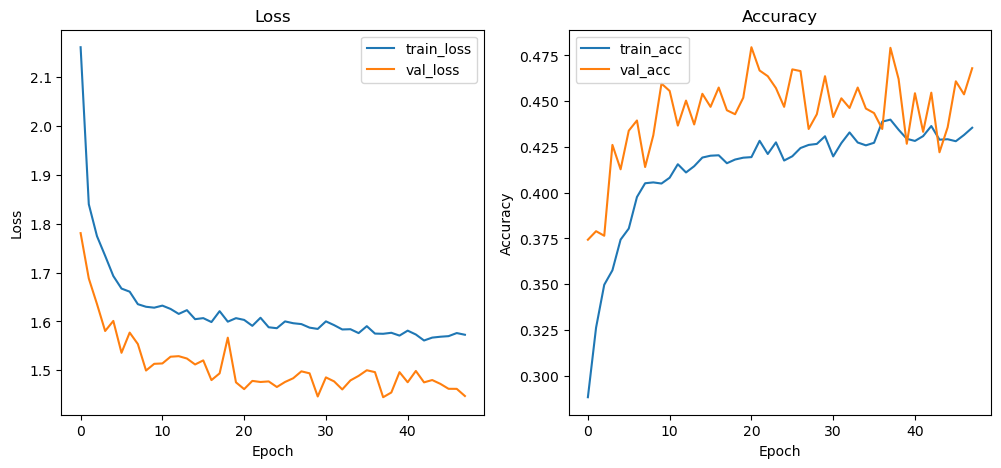

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [31]:
# model = load_model("mp_rgb_model.h5")
model = load_model("../saved_models/mp_rgb_model.h5")

In [33]:
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

# load test data
X_test, y_test = load_keypoints_dataset("../keypoints_dataset/test")

# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_test shape: (14518, 1404)
y_test_cat shape: (14518, 8)


In [34]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = np.argmax(y_test_cat, axis=1)  # one-hot

454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [35]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytrue, yhat)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 43.69%
